Problem 2B: Crypto Portfolio
Ris

In [720]:
#import libraries
import yfinance as yf                     
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

[*********************100%***********************]  1 of 1 completed


Ticker           BTC-USD
Date                    
2026-01-08  91027.125000
2026-01-09  90513.101562
2026-01-10  90386.648438
2026-01-11  90827.460938
2026-01-12  91192.992188
2026-01-13  95321.781250
2026-01-14  96929.328125
2026-01-15  95551.187500
2026-01-16  95525.117188
2026-01-17  95099.921875
Price movement of Bitcoin over last 60 days-


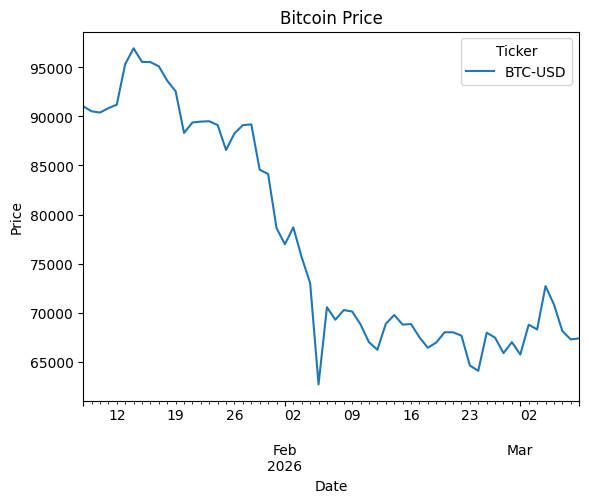

In [721]:
#import data for 1 coin
data1=yf.download('BTC-USD',period='60d')['Close']
print(data1.head(10))

print("Price movement of Bitcoin over last 60 days-")
data1.plot()
plt.title("Bitcoin Price")
plt.ylabel("Price")
plt.show()

Bitcoin log returns (last 60 days)


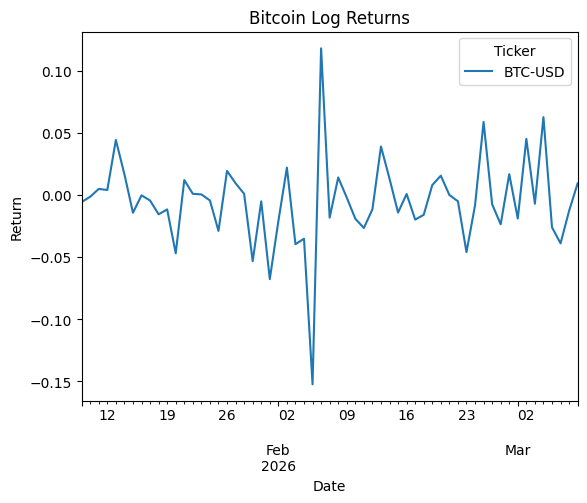

In [722]:
#Computing log returns
returns=np.log(data/data.shift(1))
returns=returns.dropna()

print("Bitcoin log returns (last 60 days)")
returns.plot()
plt.title("Bitcoin Log Returns")
plt.ylabel("Return")
plt.show()

In [723]:
#Bayesian Model Functions
def likelihood(sigma,data):
    if sigma<=0:
        return 0
    n=len(data)
    a=(1/(np.sqrt(2*np.pi)*sigma))**n
    e=np.exp(-np.sum(data**2)/(2*sigma**2))

    return a*e

def prior(sigma):
    if sigma<=0:
        return 0

    return np.exp(-sigma**2/2)

def posterior(sigma, data):
    return (prior(sigma))*(likelihood(sigma,data))



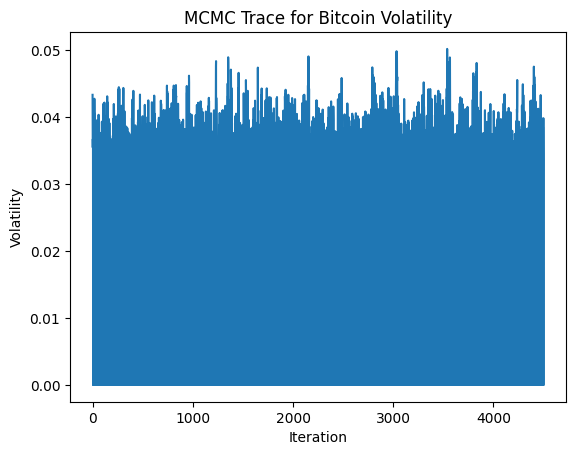

In [724]:
#MCMC Sampling
def mcmc(data,n_samples=5000):
    samples=np.zeros(n_samples)
    sigma_current = 0.03
    for i in range(n_samples):
        sigma_proposal=abs(sigma_current+np.random.normal(0,0.005))
        accept_ratio=(posterior(sigma_proposal,data)/posterior(sigma_current,data))
        if np.random.rand()<accept_ratio:
            sigma_current = sigma_proposal
            samples[i] = sigma_current

    return samples

btc_samples_withburnin=mcmc(returns.values)
btc_samples=btc_samples_withburnin[500:]      #remove burnin
plt.plot(btc_samples)
plt.title("MCMC Trace for Bitcoin Volatility")
plt.xlabel("Iteration")
plt.ylabel("Volatility")
plt.show()

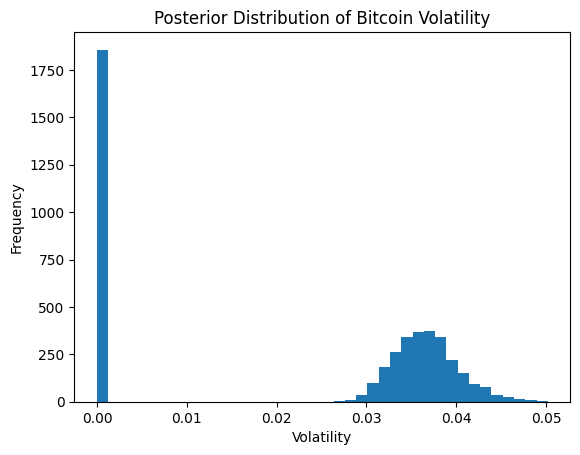

In [725]:
plt.hist(btc_samples,bins=40)
plt.title("Posterior Distribution of Bitcoin Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.show()

In [726]:
#Volatility estimate
mean_vol=np.mean(btc_samples[btc_samples>0.01])
lower=np.percentile(btc_samples[btc_samples>0.01],2.5)          #95 percent confidence interval
upper=np.percentile(btc_samples[btc_samples>0.01],97.5)
print("Mean volatility(BTC):",mean_vol)
print("95% interval:","[",lower,upper,"]")

Mean volatility(BTC): 0.03668490021770459
95% interval: [ 0.030499744276763427 0.04437910059346133 ]


GENERALIZED CODE FOR 5 COINS

[*********************100%***********************]  5 of 5 completed


Ticker       ADA-USD       BTC-USD      ETH-USD   LINK-USD     SOL-USD
Date                                                                  
2026-01-08  0.395645  91027.125000  3104.382568  13.215399  138.293427
2026-01-09  0.390703  90513.101562  3083.047119  13.117958  135.756393
2026-01-10  0.387918  90386.648438  3082.395996  13.129127  135.727005
2026-01-11  0.390285  90827.460938  3118.885254  13.174175  139.490463
2026-01-12  0.385905  91192.992188  3092.325195  13.068761  139.136185
Price movement of following coins over last 60 days-


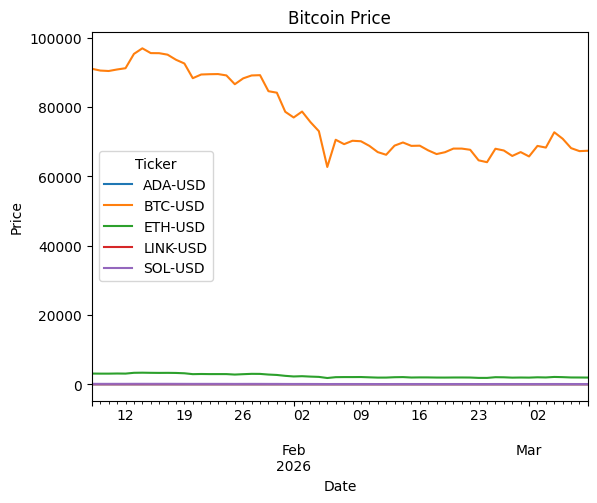

In [727]:
coins=["BTC-USD","ETH-USD","ADA-USD","SOL-USD","LINK-USD"]
prices=yf.download(coins,period="60d")["Close"]
print(prices.head())
print("Price movement of following coins over last 60 days-")
prices.plot()
plt.title("Bitcoin Price")
plt.ylabel("Price")
plt.show()


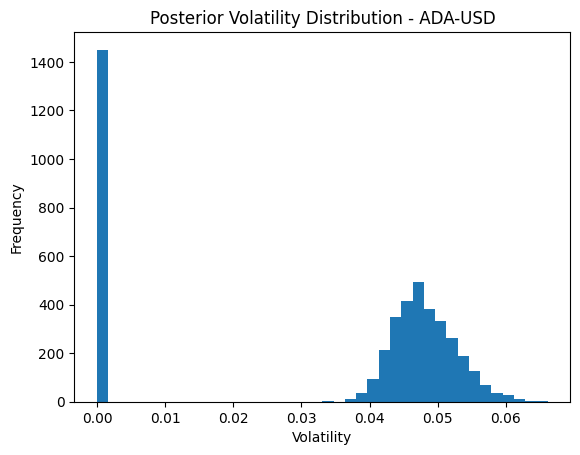

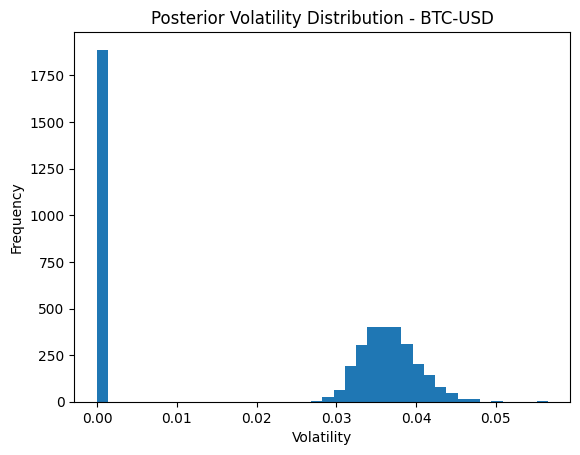

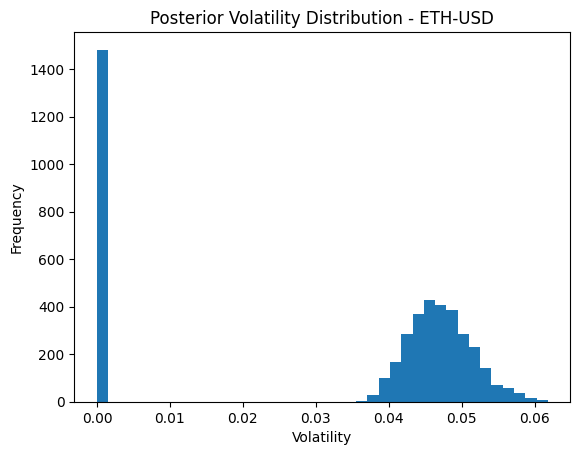

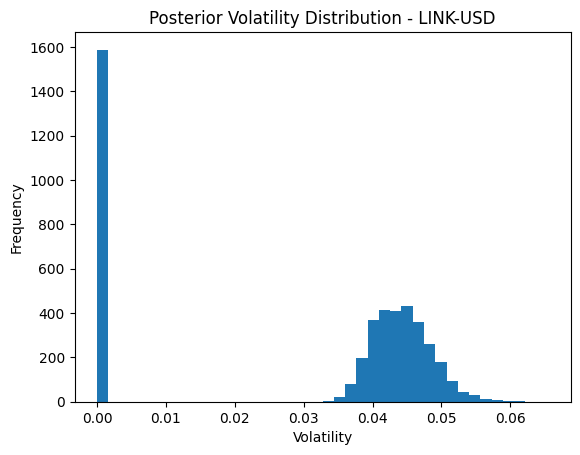

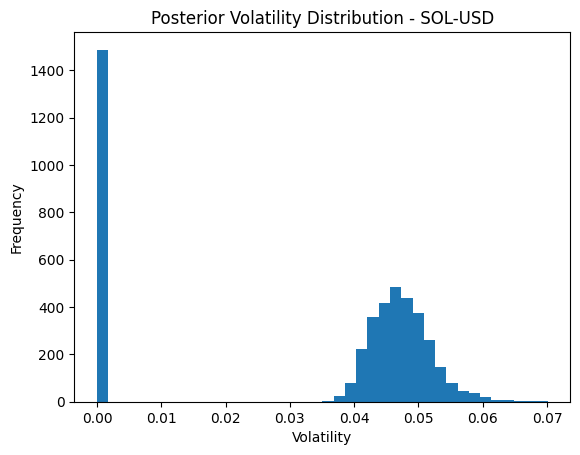

                  ADA-USD   BTC-USD   ETH-USD  LINK-USD   SOL-USD
Mean Volatility  0.048157  0.036691  0.047101  0.044324  0.047403
2.5%             0.040302  0.030826  0.039493  0.037106  0.039797
97.5%            0.057945  0.044399  0.056369  0.053245  0.057839


In [728]:
def compute_returns(data):
    returns=np.log(data/data.shift(1))
    returns=returns.dropna()
    return returns

#define posterior function same as before

#define MCMC sampling function as before
returns=compute_returns(prices)
results={}
for coin in returns.columns:
    samples=mcmc(returns[coin].values)
    samples=samples[500:]   # remove burn-in
    mean_vol=np.mean(samples[samples>0.01])
    lower=np.percentile(samples[samples>0.01],2.5)
    upper=np.percentile(samples[samples>0.01],97.5)
    plt.hist(samples, bins=40)
    plt.title(f"Posterior Volatility Distribution - {coin}")
    plt.xlabel("Volatility")
    plt.ylabel("Frequency")
    plt.show()

    results[coin]=[mean_vol, lower, upper]

vol_table=pd.DataFrame(results,index=["Mean Volatility","2.5%","97.5%"])

print(vol_table)

Equal-weight portfolio volatility with uncertainty range

In [729]:
print("\nComputing equal weight portfolio risk...")
weights=np.repeat(1/5,5)
cov_matrix=returns.cov()
portfolio_volatility=np.sqrt(weights @ cov_matrix @ weights)
print("Equal weight portfolio volatility:",portfolio_volatility)


Computing equal weight portfolio risk...
Equal weight portfolio volatility: 0.04203118351536145


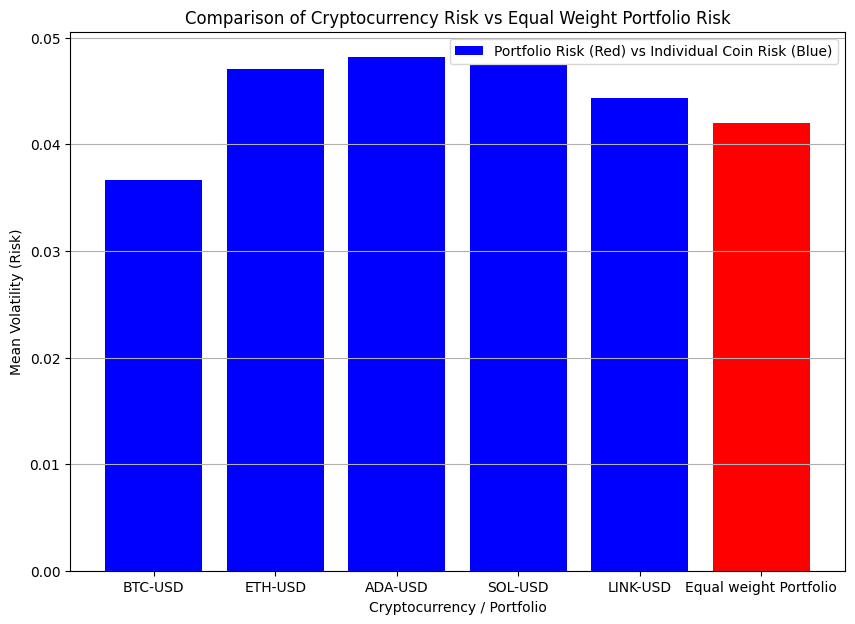

In [730]:
coin=list(results.keys())
mean_vols=[results[c][0] for c in coins]
labels=coins+["Equal weight Portfolio"]
values=mean_vols+[portfolio_volatility]
plt.figure(figsize=(10,7))
plt.bar(labels,values,color=["blue","blue","blue","blue","blue","red"])
plt.xlabel("Cryptocurrency / Portfolio")
plt.ylabel("Mean Volatility (Risk)")
plt.title("Comparison of Cryptocurrency Risk vs Equal Weight Portfolio Risk")
plt.legend(["Portfolio Risk (Red) vs Individual Coin Risk (Blue)"])
plt.grid(axis="y")
plt.show()

Higher the mean volatility , higher the risk. Among the five cryptocurrencies, ADA shows the highest volatility(08-03-2026), indicating that it carries the greatest risk. Its posterior mean volatility is higher than the other coins, meaning its daily price fluctuations are larger.
Posterior distributions are concentrated around the mean values, and the 95% credible intervals are relatively narrow. This means that most of the sampled volatility values fall within a small range, indicating stable estimates from the data. Therefore, the model provides strong evidence about the relative risk levels of the cryptocurrencies, and we can be confident in identifying the asset with the highest volatility.

In the equal-weight portfolio, each cryptocurrency receives the same investment proportion (20%).This is called Diversification. When one coin experiences large fluctuations, the others may move differently or more moderately. As a result, the combined portfolio volatility is often lower than the volatility of the most risky individual coin.